In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import pickle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns

In [3]:
IMG_SIZE = 224

def load_dataset(base_path):
    X = []
    y = []
    class_names = sorted(os.listdir(base_path))
    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        if not os.path.isdir(cls_folder):
            continue
        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Convert B/W or grayscale to RGB
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), class_names

In [4]:
dataset_path = "/content/drive/MyDrive/brain-tumor-classification/data/processed/Training"
X, y, class_names = load_dataset(dataset_path)
print("Dataset loaded:", X.shape, y.shape)
print("Classes:", class_names)

Dataset loaded: (2870, 224, 224, 3) (2870,)
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Pixel range: 0 → 255


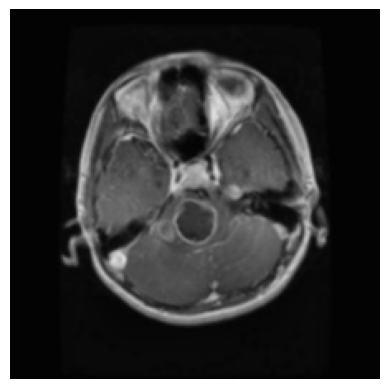

In [5]:
print("Pixel range:", X.min(), "→", X.max())
plt.imshow(X[0])
plt.axis("off")
plt.show()

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42, stratify=y_train_full
)

# Convert y → one-hot
y_train_cat = to_categorical(y_train, num_classes=len(class_names))
y_val_cat = to_categorical(y_val, num_classes=len(class_names))
y_test_cat = to_categorical(y_test, num_classes=len(class_names))

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2324, 224, 224, 3)
Validation: (259, 224, 224, 3)
Test: (287, 224, 224, 3)


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=[1.0, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow(X_train, y_train_cat, batch_size=32, shuffle=True)
val_gen = val_datagen.flow(X_val, y_val_cat, batch_size=32)
test_gen = test_datagen.flow(X_test, y_test_cat, batch_size=32)

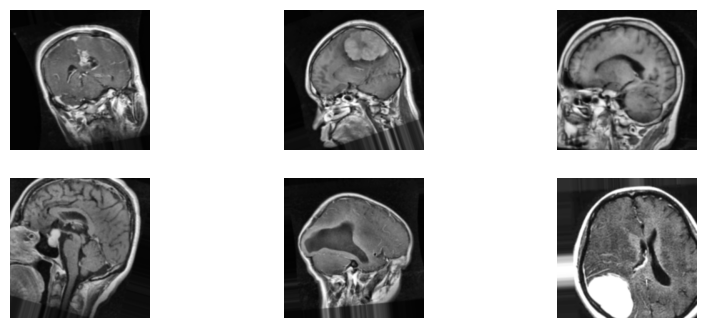

In [8]:
images, labels = next(train_gen)
plt.figure(figsize=(10,4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

In [17]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

# Unfreeze the last few layers of ResNet50 for fine-tuning
base_model.trainable = True

# Freeze all layers except the last 15 layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Trainable layers: {sum([1 for layer in base_model.layers if layer.trainable])}")

# Build the model architecture
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu", kernel_regularizer='l2')(x)  # Increased neurons
x = Dropout(0.5)(x)  # Increased dropout
x = Dense(256, activation="relu", kernel_regularizer='l2')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)  # Additional layer
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Use a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Reduced learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Total layers in base model: 175
Trainable layers: 15


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,801,540 (94.61 MB)

 Trainable params: 6,734,212 (25.69 MB)

 Non-trainable params: 18,067,328 (68.92 MB)

In [18]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Calculate steps per epoch based on total training samples
steps_per_epoch = len(X_train) // 32

# Create callbacks for better training
# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Stop training if no improvement for 8 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Save the best model during training
checkpoint_path = "/content/drive/MyDrive/brain-tumor-classification/models/best_model_checkpoint.h5"
model_checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Train the model
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=50,  # Increased epochs (early stopping will stop if needed)
    validation_data=val_gen,
    callbacks=[reduce_lr, early_stop, model_checkpoint]
)

print("\nTraining completed!")
print(f"Best model saved at: {checkpoint_path}")

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.3261 - loss: 12.4486
Epoch 1: val_accuracy improved from -inf to 0.32432, saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_model_checkpoint.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 664ms/step - accuracy: 0.3268 - loss: 12.4397 - val_accuracy: 0.3243 - val_loss: 10.6711 - learning_rate: 1.0000e-04
Epoch 2/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.4375 - loss: 10.6454

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.32432 to 0.33205, saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_model_checkpoint.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4375 - loss: 10.6454 - val_accuracy: 0.3320 - val_loss: 10.6407 - learning_rate: 1.0000e-04
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.5097 - loss: 10.0231
Epoch 3: val_accuracy improved from 0.33205 to 0.53282, saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_model_checkpoint.h5


...

72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 498ms/step - accuracy: 0.6286 - loss: 6.0084 - val_accuracy: 0.7336 - val_loss: 5.2288 - learning_rate: 1.0000e-04
Epoch 10/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.7188 - loss: 5.2351
Epoch 10: val_accuracy improved from 0.73359 to 0.74517, saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_model_checkpoint.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7188 - loss: 5.2351 - val_accuracy: 0.7452 - val_loss: 5.1998 - learning_rate: 1.0000e-04
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.6500 - loss: 5.2078
Epoch 11: val_accuracy did not improve from 0.74517
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 462ms/step - accuracy: 0.6499 - loss: 5.2060 - val_accuracy: 0.5598 - val_loss: 4.8414 - learning_rate: 1.0000e-04
Epoch 12/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.6250 - loss: 4.8825
Epoch 12: val_accuracy did not improve from 0.74517
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6250 - loss: 4.8825 - val_accuracy: 0.5792 - val_loss: 4.7782 - learning_rate: 1.0000e-04
Epoch 13/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6547 - loss: 4.5882
Epoch 13: val_accuracy did not improve from 0.74517
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 425ms/step - accuracy: 0.6547 - loss: 4.5866 - val_accuracy: 0.6371 - val_loss: 4.2479 - learning_rate: 1.0000e-04
Epoc

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6562 - loss: 3.5345 - val_accuracy: 0.7606 - val_loss: 3.2484 - learning_rate: 1.0000e-04
Epoch 19/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6805 - loss: 3.3227
Epoch 19: val_accuracy did not improve from 0.76062
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 462ms/step - accuracy: 0.6804 - loss: 3.3217 - val_accuracy: 0.6988 - val_loss: 3.0777 - learning_rate: 1.0000e-04
Epoch 20/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.7812 - loss: 2.9704
Epoch 20: val_accuracy did not improve from 0.76062
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7812 - loss: 2.9704 - val_accuracy: 0.6950 - val_loss: 3.1200 - learning_rate: 1.0000e-04
Epoch 21/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6642 - loss: 3.0709
Epoch 21: val_accuracy did not improve from 0.76062
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 420ms/step - accuracy: 0.6643 - loss: 3.0700 - val_accuracy: 0.7220 - val_loss: 2.7232 - learning_rate: 1.0000e-04
Epoc

72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 538ms/step - accuracy: 0.7141 - loss: 2.5791 - val_accuracy: 0.7992 - val_loss: 2.3447 - learning_rate: 5.0000e-05
Epoch 26/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8125 - loss: 2.3106
Epoch 26: val_accuracy did not improve from 0.79923
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8125 - loss: 2.3106 - val_accuracy: 0.7722 - val_loss: 2.3543 - learning_rate: 5.0000e-05
Epoch 27/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.7289 - loss: 2.4458
Epoch 27: val_accuracy did not improve from 0.79923
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 469ms/step - accuracy: 0.7288 - loss: 2.4455 - val_accuracy: 0.7452 - val_loss: 2.2761 - learning_rate: 5.0000e-05
Epoch 28/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.8438 - loss: 2.2748
Epoch 28: val_accuracy did not improve from 0.79923
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8438 - loss: 2.2748 - val_accuracy: 0.7452 - val_loss: 2.2764 - learning_rate: 5.0000e-05
Epoc

72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 467ms/step - accuracy: 0.7005 - loss: 2.2450 - val_accuracy: 0.8147 - val_loss: 2.0347 - learning_rate: 2.5000e-05
Epoch 34/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.7500 - loss: 2.0707
Epoch 34: val_accuracy did not improve from 0.81467
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7500 - loss: 2.0707 - val_accuracy: 0.8147 - val_loss: 2.0401 - learning_rate: 2.5000e-05
Epoch 35/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.7527 - loss: 2.1466
Epoch 35: val_accuracy did not improve from 0.81467
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 452ms/step - accuracy: 0.7525 - loss: 2.1467 - val_accuracy: 0.7761 - val_loss: 2.0067 - learning_rate: 2.5000e-05
Epoch 36/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6562 - loss: 2.1716
Epoch 36: val_accuracy did not improve from 0.81467
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6562 - loss: 2.1716 - val_accuracy: 0.7761 - val_loss: 2.0080 - learning_rate: 2.5000e-05
Epoc

In [19]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 459ms/step - accuracy: 0.7487 - loss: 1.8672
Test Accuracy: 0.7665505409240723


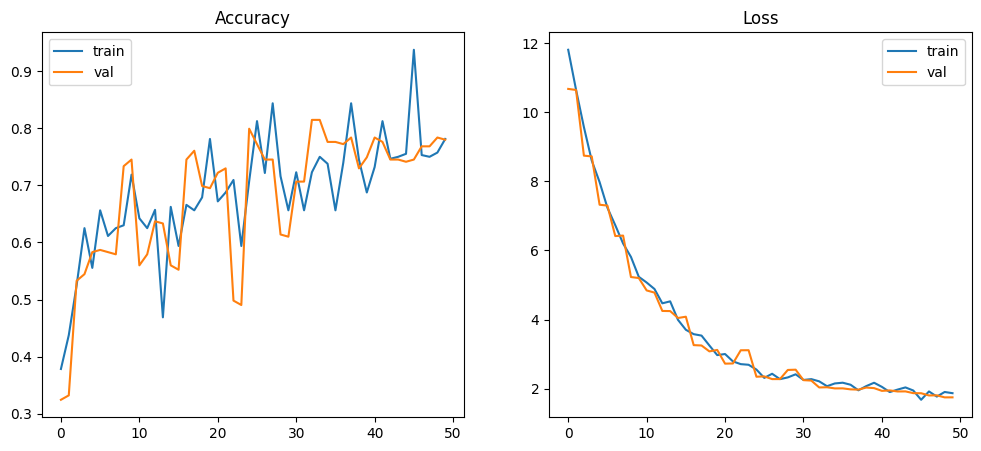

In [20]:
plt.figure(figsize=(12,5))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["train", "val"])
# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [21]:
model_save_path = "/content/drive/MyDrive/brain-tumor-classification/models/ResNet50"
os.makedirs(model_save_path, exist_ok=True)

# Save the entire model as .pkl
model_file = os.path.join(model_save_path, "resnet50_brain_tumor_model.pkl")
with open(model_file, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved successfully at: {model_file}")

# Also save as .h5 for better compatibility
h5_file = os.path.join(model_save_path, "resnet50_brain_tumor_model.h5")
model.save(h5_file)
print(f"Model also saved as .h5 at: {h5_file}")

# Save class names
class_names_file = os.path.join(model_save_path, "class_names.pkl")
with open(class_names_file, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Class names saved at: {class_names_file}")

Model saved successfully at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/resnet50_brain_tumor_model.pkl
Model also saved as .h5 at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/resnet50_brain_tumor_model.h5
Class names saved at: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/class_names.pkl


In [22]:
X_test_normalized = X_test / 255.0  # Normalize same as test_gen
y_pred_probs = model.predict(X_test_normalized, batch_size=32, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # Original labels (not one-hot)

print("\nPredictions shape:", y_pred.shape)
print("True labels shape:", y_true.shape)
print("Sample predictions:", y_pred[:10])
print("Sample true labels:", y_true[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 530ms/step

Predictions shape: (287,)
True labels shape: (287,)
Sample predictions: [0 0 1 1 0 3 0 2 1 2]
Sample true labels: [0 0 1 0 3 3 0 2 1 2]


In [23]:
print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)

# Overall Accuracy - This should match Keras evaluation
overall_accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Keras Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Difference: {abs(overall_accuracy - acc):.6f}")

# Overall Precision, Recall, F1-Score
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')
overall_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nOverall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")
print(f"Overall F1-Score: {overall_f1:.4f}")

# Macro averages (unweighted)
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f"\nMacro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")


OVERALL METRICS
Overall Accuracy: 0.7666 (76.66%)
Keras Test Accuracy: 0.7666 (76.66%)
Difference: 0.000000

Overall Precision: 0.7657
Overall Recall: 0.7666
Overall F1-Score: 0.7593

Macro Precision: 0.7702
Macro Recall: 0.7595
Macro F1-Score: 0.7586


In [24]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT (CLASS-WISE METRICS)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)


CLASSIFICATION REPORT (CLASS-WISE METRICS)
                  precision    recall  f1-score   support

    glioma_tumor     0.7816    0.8193    0.8000        83
meningioma_tumor     0.7419    0.5610    0.6389        82
        no_tumor     0.8000    0.7179    0.7568        39
 pituitary_tumor     0.7573    0.9398    0.8387        83

        accuracy                         0.7666       287
       macro avg     0.7702    0.7595    0.7586       287
    weighted avg     0.7657    0.7666    0.7593       287



In [25]:
print("\n" + "="*60)
print("CLASS-WISE DETAILED METRICS")
print("="*60)

for i, class_name in enumerate(class_names):
    # Get indices where true label is this class
    class_indices = np.where(y_true == i)[0]

    if len(class_indices) > 0:
        # Get predictions for this class
        class_predictions = y_pred[class_indices]

        # Calculate metrics
        class_correct = np.sum(class_predictions == i)
        class_total = len(class_indices)
        class_accuracy = class_correct / class_total

        # True Positives, False Positives, False Negatives
        tp = class_correct
        fp = np.sum(y_pred == i) - tp  # Predicted as this class but actually not
        fn = class_total - tp  # Actually this class but predicted as other

        # Precision and Recall for this class
        class_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        class_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0

        print(f"\n{class_name}:")
        print(f"  Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")
        print(f"  Correct: {class_correct}/{class_total}")
        print(f"  Precision: {class_precision:.4f}")
        print(f"  Recall: {class_recall:.4f}")
        print(f"  F1-Score: {class_f1:.4f}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}")


CLASS-WISE DETAILED METRICS

glioma_tumor:
  Accuracy: 0.8193 (81.93%)
  Correct: 68/83
  Precision: 0.7816
  Recall: 0.8193
  F1-Score: 0.8000
  TP: 68, FP: 19, FN: 15

meningioma_tumor:
  Accuracy: 0.5610 (56.10%)
  Correct: 46/82
  Precision: 0.7419
  Recall: 0.5610
  F1-Score: 0.6389
  TP: 46, FP: 16, FN: 36

no_tumor:
  Accuracy: 0.7179 (71.79%)
  Correct: 28/39
  Precision: 0.8000
  Recall: 0.7179
  F1-Score: 0.7568
  TP: 28, FP: 7, FN: 11

pituitary_tumor:
  Accuracy: 0.9398 (93.98%)
  Correct: 78/83
  Precision: 0.7573
  Recall: 0.9398
  F1-Score: 0.8387
  TP: 78, FP: 25, FN: 5



CONFUSION MATRIX

Raw Confusion Matrix:
[[68  9  0  6]
 [15 46  7 14]
 [ 2  4 28  5]
 [ 2  3  0 78]]

Rows = True Labels, Columns = Predicted Labels


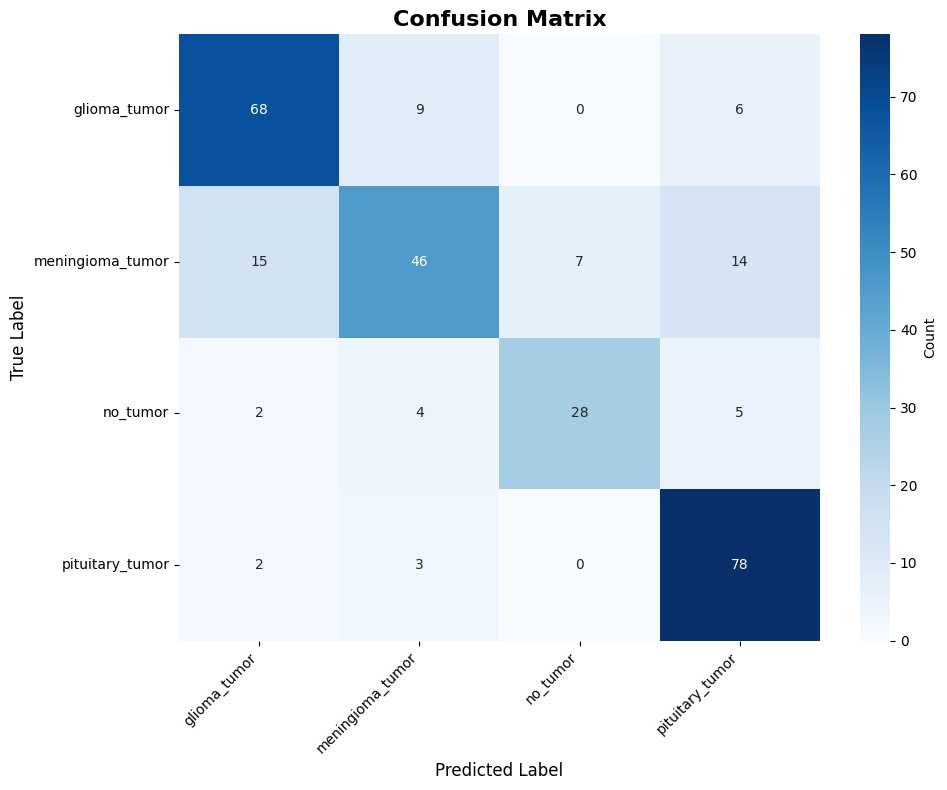

In [26]:
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_true, y_pred)
print("\nRaw Confusion Matrix:")
print(cm)
print("\nRows = True Labels, Columns = Predicted Labels")

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Normalized Confusion Matrix (by row):
[[0.81927711 0.10843373 0.         0.07228916]
 [0.18292683 0.56097561 0.08536585 0.17073171]
 [0.05128205 0.1025641  0.71794872 0.12820513]
 [0.02409639 0.03614458 0.         0.93975904]]


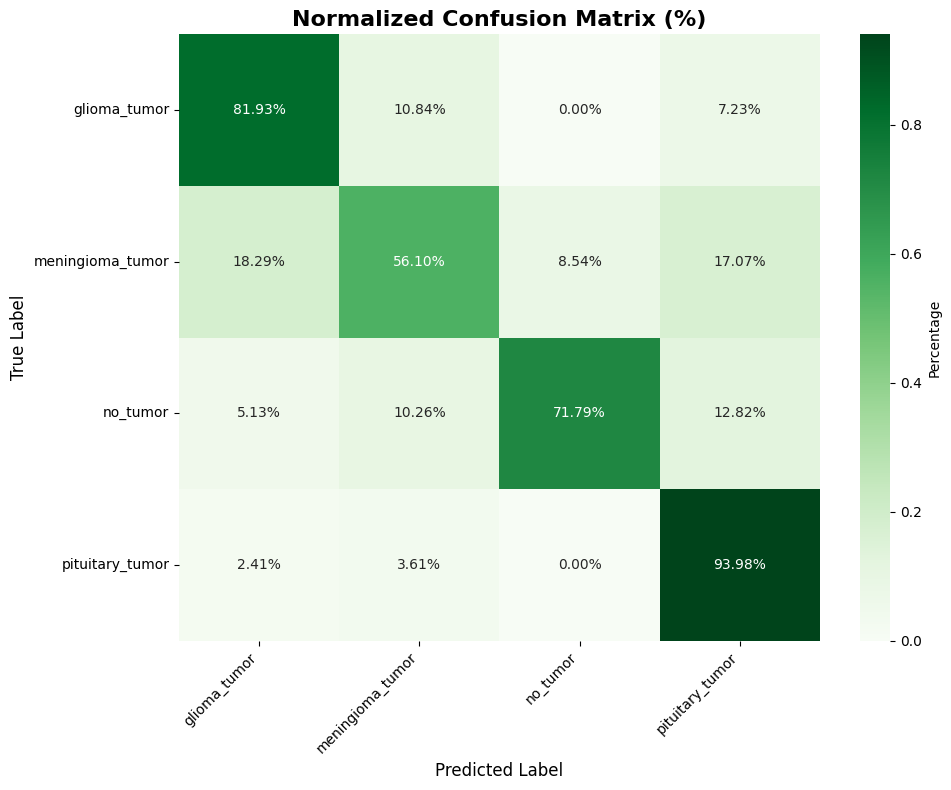

In [27]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\nNormalized Confusion Matrix (by row):")
print(cm_normalized)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix (%)', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

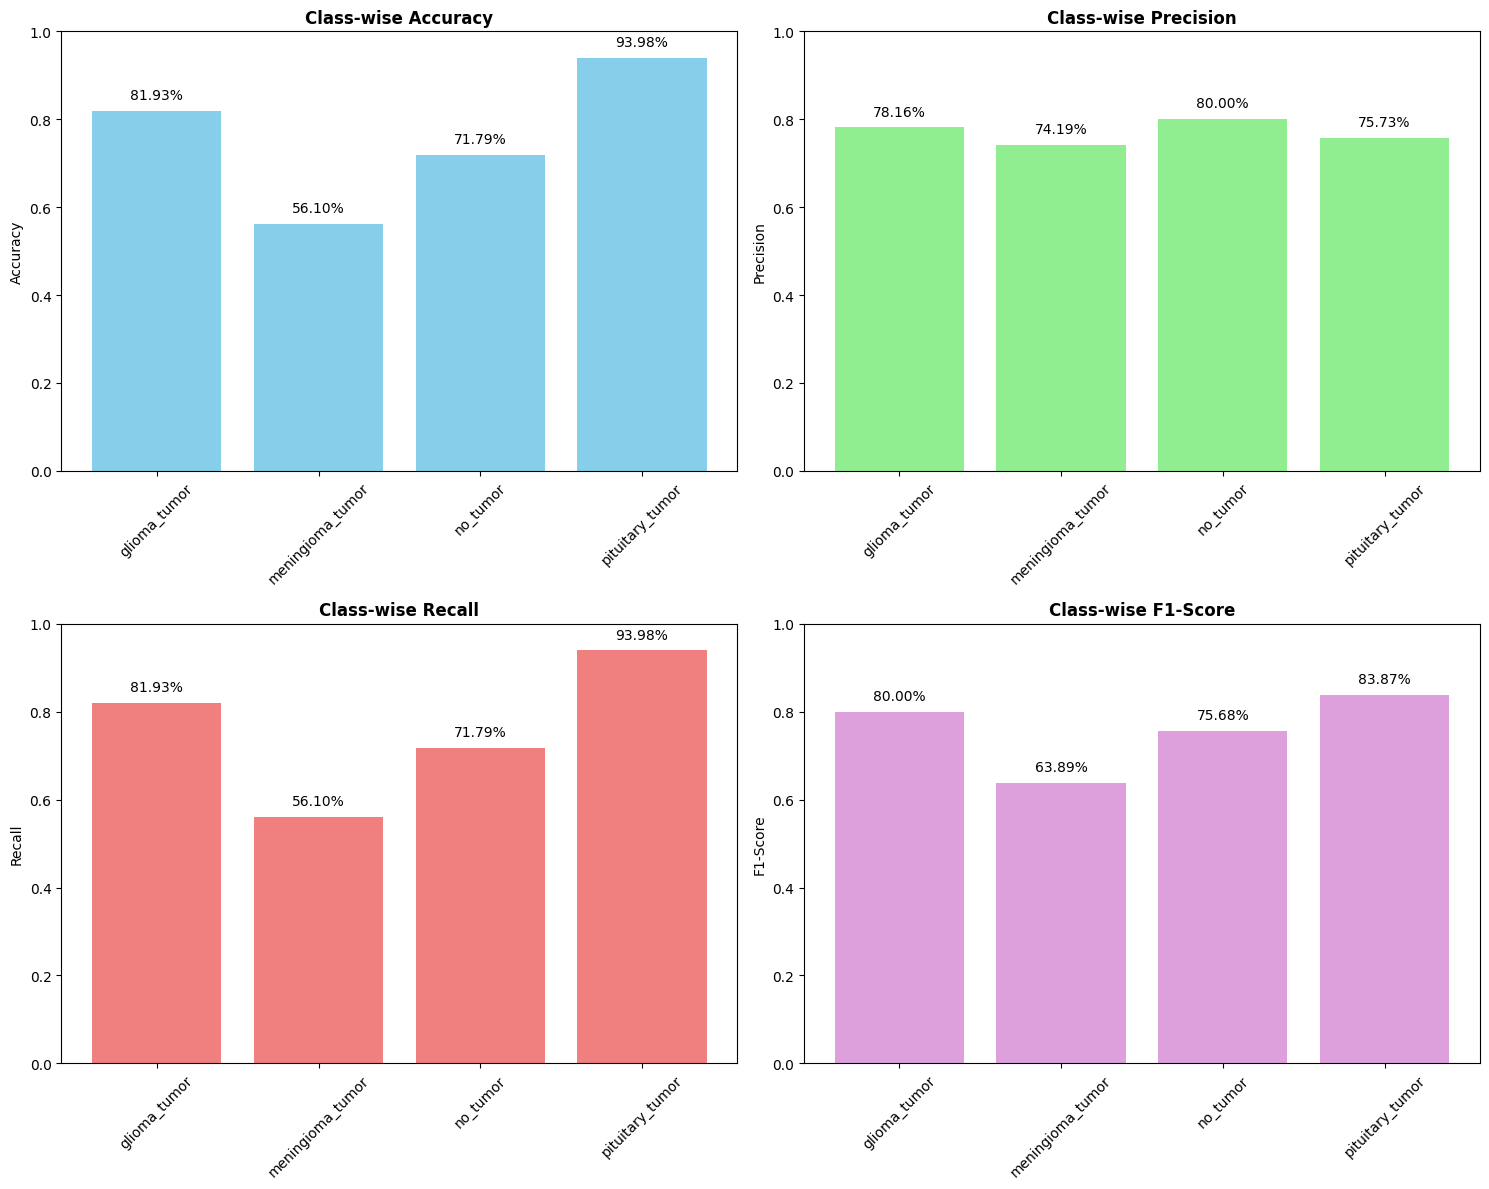

In [28]:
class_accuracies = []
class_precisions = []
class_recalls = []
class_f1_scores = []

for i in range(len(class_names)):
    class_indices = np.where(y_true == i)[0]
    if len(class_indices) > 0:
        class_predictions = y_pred[class_indices]
        class_acc = np.sum(class_predictions == i) / len(class_indices)

        tp = np.sum(class_predictions == i)
        fp = np.sum(y_pred == i) - tp
        fn = len(class_indices) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        class_accuracies.append(class_acc)
        class_precisions.append(precision)
        class_recalls.append(recall)
        class_f1_scores.append(f1)

# Plot per-class metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0, 0].bar(class_names, class_accuracies, color='skyblue')
axes[0, 0].set_title('Class-wise Accuracy', fontweight='bold')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

# Precision
axes[0, 1].bar(class_names, class_precisions, color='lightgreen')
axes[0, 1].set_title('Class-wise Precision', fontweight='bold')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_precisions):
    axes[0, 1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

# Recall
axes[1, 0].bar(class_names, class_recalls, color='lightcoral')
axes[1, 0].set_title('Class-wise Recall', fontweight='bold')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_recalls):
    axes[1, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

# F1-Score
axes[1, 1].bar(class_names, class_f1_scores, color='plum')
axes[1, 1].set_title('Class-wise F1-Score', fontweight='bold')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_f1_scores):
    axes[1, 1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [29]:
metrics_file = os.path.join(model_save_path, "model_metrics.txt")
with open(metrics_file, 'w') as f:
    f.write("="*60 + "\n")
    f.write("BRAIN TUMOR CLASSIFICATION - MODEL EVALUATION METRICS\n")
    f.write("="*60 + "\n\n")

    f.write("="*60 + "\n")
    f.write("OVERALL METRICS\n")
    f.write("="*60 + "\n")
    f.write(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)\n")
    f.write(f"Keras Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
    f.write(f"Difference: {abs(overall_accuracy - acc):.6f}\n\n")

    f.write(f"Weighted Precision: {overall_precision:.4f}\n")
    f.write(f"Weighted Recall: {overall_recall:.4f}\n")
    f.write(f"Weighted F1-Score: {overall_f1:.4f}\n\n")

    f.write(f"Macro Precision: {macro_precision:.4f}\n")
    f.write(f"Macro Recall: {macro_recall:.4f}\n")
    f.write(f"Macro F1-Score: {macro_f1:.4f}\n\n")

    f.write("="*60 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("="*60 + "\n")
    f.write(report)
    f.write("\n")

    f.write("="*60 + "\n")
    f.write("CLASS-WISE DETAILED METRICS\n")
    f.write("="*60 + "\n")
    for i, class_name in enumerate(class_names):
        class_indices = np.where(y_true == i)[0]
        if len(class_indices) > 0:
            class_predictions = y_pred[class_indices]
            class_correct = np.sum(class_predictions == i)
            class_total = len(class_indices)
            class_accuracy = class_correct / class_total

            tp = class_correct
            fp = np.sum(y_pred == i) - tp
            fn = class_total - tp

            class_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            class_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0

            f.write(f"\n{class_name}:\n")
            f.write(f"  Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)\n")
            f.write(f"  Correct: {class_correct}/{class_total}\n")
            f.write(f"  Precision: {class_precision:.4f}\n")
            f.write(f"  Recall: {class_recall:.4f}\n")
            f.write(f"  F1-Score: {class_f1:.4f}\n")
            f.write(f"  TP: {tp}, FP: {fp}, FN: {fn}\n")

    f.write("\n")
    f.write("="*60 + "\n")
    f.write("CONFUSION MATRIX\n")
    f.write("="*60 + "\n")
    f.write("Rows = True Labels, Columns = Predicted Labels\n\n")
    f.write(str(cm))
    f.write("\n\n")
    f.write("Normalized Confusion Matrix:\n")
    f.write(str(cm_normalized))

print(f"\nAll metrics saved to: {metrics_file}")


All metrics saved to: /content/drive/MyDrive/brain-tumor-classification/models/ResNet50/model_metrics.txt


In [30]:
print("\n" + "="*60)
print("LOADING SAVED MODEL AND MAKING PREDICTIONS")
print("="*60)

# Load the model
with open(model_file, 'rb') as f:
    loaded_model = pickle.load(f)
print("Model loaded successfully!")

# Load class names
with open(class_names_file, 'rb') as f:
    loaded_class_names = pickle.load(f)
print("Class names loaded:", loaded_class_names)


LOADING SAVED MODEL AND MAKING PREDICTIONS
Model loaded successfully!
Class names loaded: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [31]:
def predict_image(model, img_array, class_names):
    """
    Predict the class of a single image

    Args:
        model: Trained model
        img_array: Image array (already resized to 224x224)
        class_names: List of class names

    Returns:
        predicted_class, confidence, all_probabilities
    """
    # Ensure image is in correct format
    if img_array.max() > 1.0:
        img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]

    return class_names[predicted_class_idx], confidence, predictions[0]

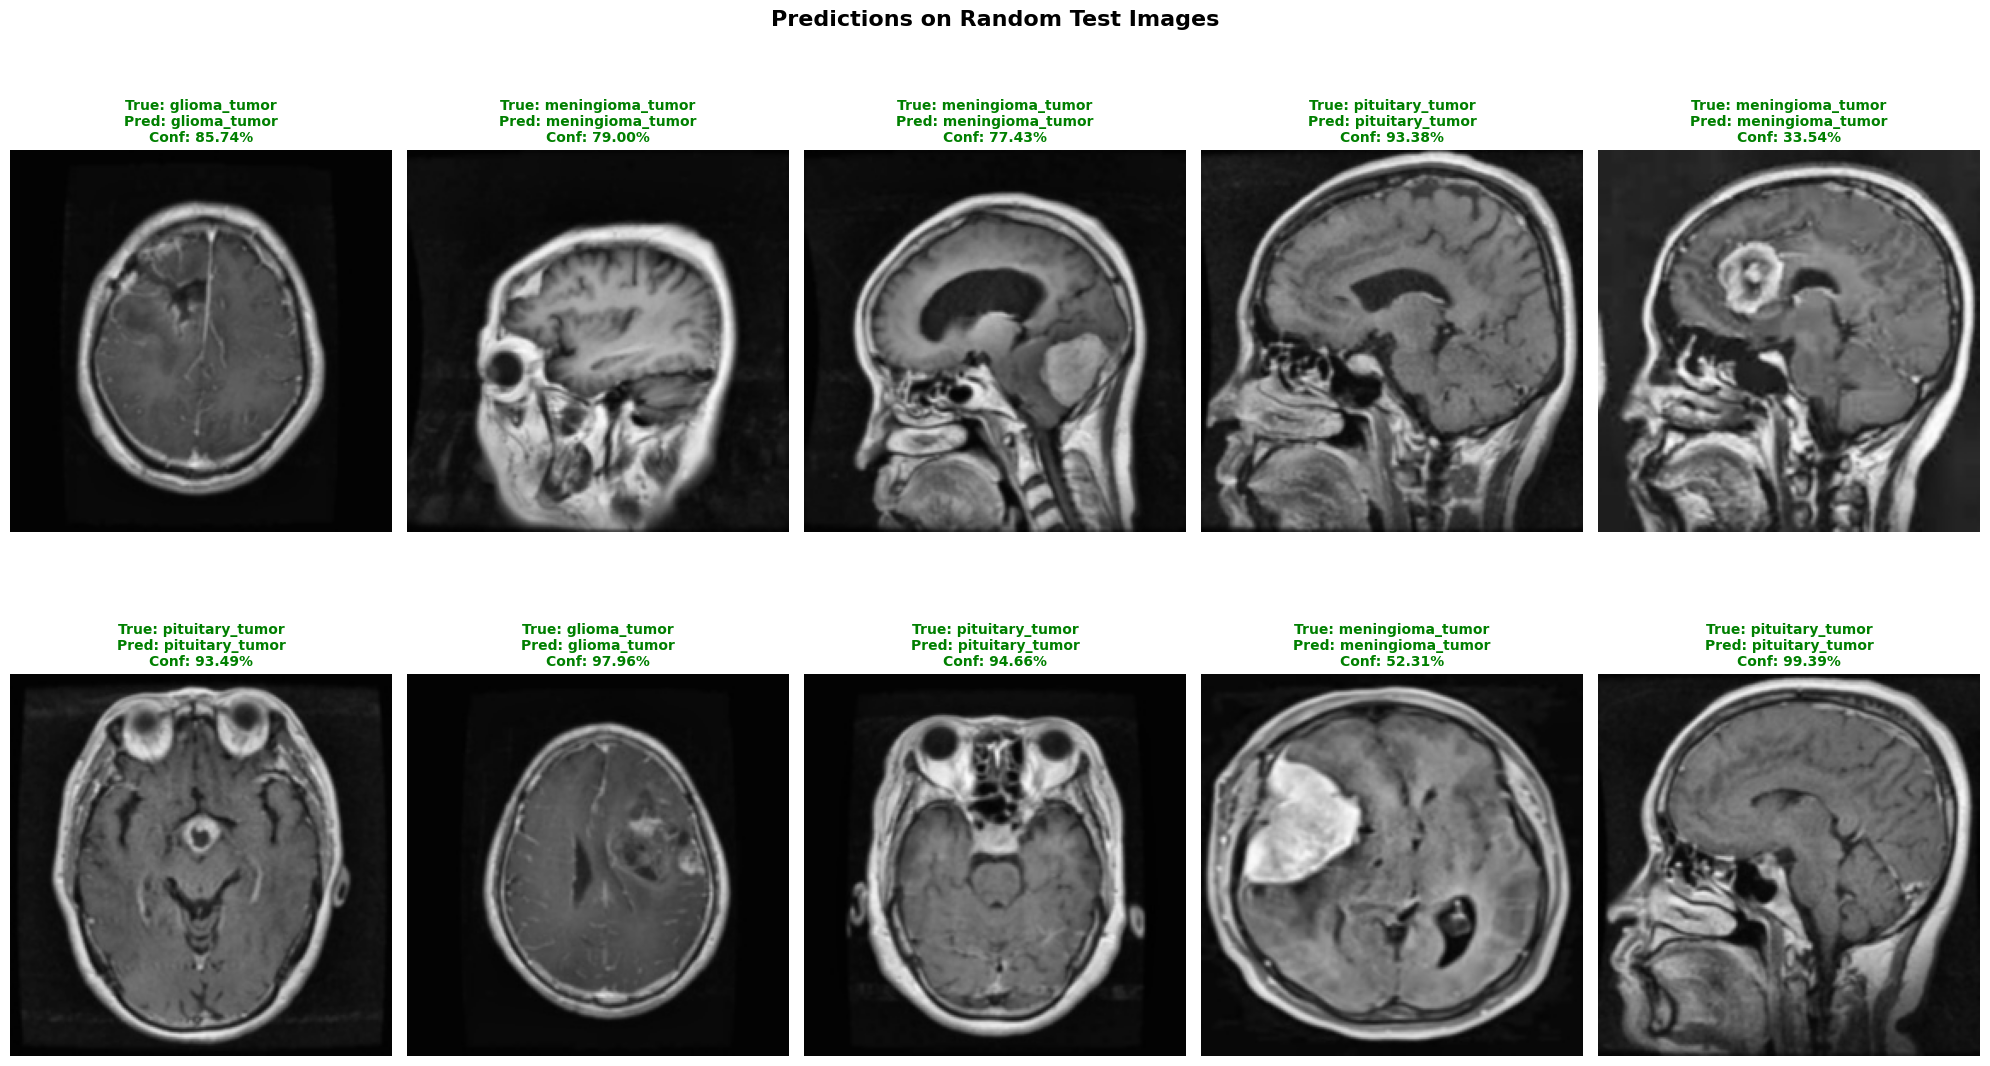

In [33]:
num_samples = 10
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(20, 12))
for idx, i in enumerate(random_indices):
    img = X_test[i]
    true_label = class_names[y_test[i]]

    # Predict
    pred_class, confidence, all_probs = predict_image(loaded_model, img, loaded_class_names)

    # Plot
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.axis('off')

    # Color: green if correct, red if wrong
    color = 'green' if pred_class == true_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_class}\nConf: {confidence:.2%}',
              fontsize=10, color=color, fontweight='bold')

plt.suptitle('Predictions on Random Test Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()